In [1]:
import spatialdata as sd
import spatialdata_plot
import matplotlib.pyplot as plt

/home/stefano/miniconda3/envs/analysis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [53]:
data_path = "/home/stefano/Documents/Spatial-Transcriptomic/data/blocco1_sham"
sdata = sd.read_zarr(data_path)
sdata

/tmp/ipykernel_9623/1828072172.py:2: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr(data_path)
/home/stefano/miniconda3/envs/analysis/lib/python3.11/site-packages/zarr/core/group.py:3535: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


SpatialData object, with associated Zarr store: /home/stefano/Documents/Spatial-Transcriptomic/data/blocco1_sham
├── Images
│     ├── 'blocco1_hires_image': DataArray[cyx] (3, 1849, 4270)
│     ├── 'blocco1_lowres_image': DataArray[cyx] (3, 185, 427)
│     └── 'fluo_image': DataTree[cyx] (3, 7000, 16166), (3, 3500, 8083), (3, 1750, 4041), (3, 875, 2020)
├── Shapes
│     ├── 'GFP_poly': GeoDataFrame shape: (2, 5) (2D shapes)
│     ├── 'blocco1_square_008um': GeoDataFrame shape: (171116, 2) (2D shapes)
│     ├── 'blocco1_square_016um': GeoDataFrame shape: (44363, 1) (2D shapes)
│     ├── 'intissue_008um': GeoDataFrame shape: (95232, 3) (2D shapes)
│     └── 'intissue_poly': GeoDataFrame shape: (1, 5) (2D shapes)
└── Tables
      ├── 'filtered': AnnData (95232, 32285)
      ├── 'final_table': AnnData (95514, 32285)
      ├── 'square_008um': AnnData (95514, 32285)
      └── 'square_016um': AnnData (44363, 32285)
with coordinate systems:
    ▸ 'blocco1', with elements:
        blocco1_hires

INFO     Rasterizing image for faster rendering.                                                                   


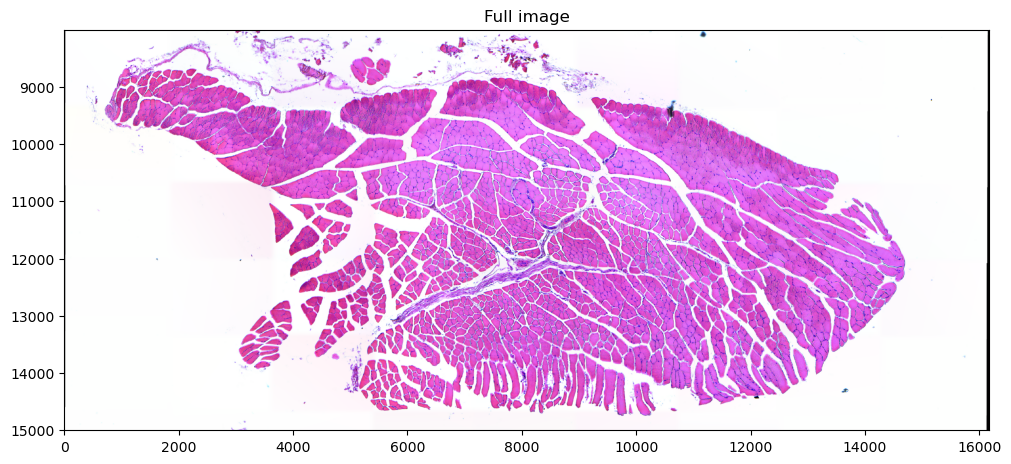

In [34]:
#plot the data
sdata.pl.render_images("blocco1_hires_image").pl.show(coordinate_systems = "blocco1", title="Full image", figsize=(10,10))


INFO     Rasterizing image for faster rendering.                                                                   


/home/stefano/miniconda3/envs/analysis/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:170: UserWarning: The table is annotating 'intissue_008um', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)


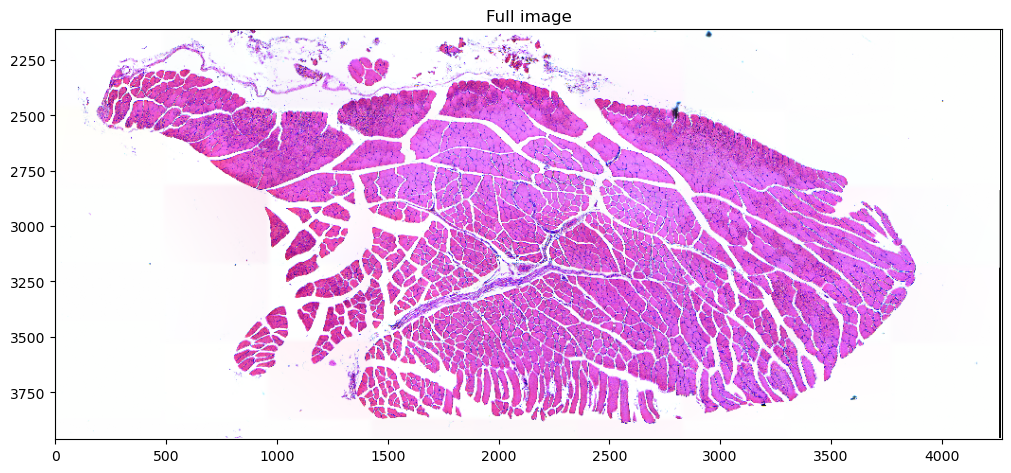

In [60]:
#plot the data
sdata.pl.render_images("blocco1_hires_image").pl.show(coordinate_systems = "blocco1_downscaled_hires", title="Full image", figsize=(10,10))


In [9]:
sdata

/home/stefano/miniconda3/envs/analysis/lib/python3.11/site-packages/zarr/core/group.py:3535: ZarrUserWarning: Object at zmetadata is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


SpatialData object, with associated Zarr store: /home/stefano/Documents/Spatial-Transcriptomic/data/blocco1_sham
├── Images
│     ├── 'blocco1_hires_image': DataArray[cyx] (3, 1849, 4270)
│     ├── 'blocco1_lowres_image': DataArray[cyx] (3, 185, 427)
│     └── 'fluo_image': DataTree[cyx] (3, 7000, 16166), (3, 3500, 8083), (3, 1750, 4041), (3, 875, 2020)
├── Shapes
│     ├── 'GFP_poly': GeoDataFrame shape: (2, 5) (2D shapes)
│     ├── 'blocco1_square_008um': GeoDataFrame shape: (171116, 2) (2D shapes)
│     ├── 'blocco1_square_016um': GeoDataFrame shape: (44363, 1) (2D shapes)
│     ├── 'intissue_008um': GeoDataFrame shape: (95232, 3) (2D shapes)
│     └── 'intissue_poly': GeoDataFrame shape: (1, 5) (2D shapes)
└── Tables
      ├── 'filtered': AnnData (95232, 32285)
      ├── 'final_table': AnnData (95514, 32285)
      ├── 'square_008um': AnnData (95514, 32285)
      └── 'square_016um': AnnData (44363, 32285)
with coordinate systems:
    ▸ 'blocco1', with elements:
        blocco1_hires

# Crop image with Napari
Try to crop a portion of the image with napari and then focus with the analysis on the cropped image

In [44]:
import napari
import numpy as np

from spatialdata.transformations import get_transformation
from spatialdata import transform
from spatialdata.transformations import set_transformation, MapAxis
from spatialdata.transformations import Identity


In [54]:
#show the transformation neeeded to fit the image in the showed  coordinate system (blocco1_downscaled_hires) (bloocco1)
"""
blocco1_downscaled_hires:
Translation 
y_blocco1_downscaled_hires = y_pixel + 2113
x_blocco1_downscaled_hires = x_pixel

blocco1 
translation and scale
y_blocco1 = (y_pixel * 3.786) + 2113
x_blocco1 = (x_pixel * 3.786) 
"""
sdata.images["blocco1_hires_image"].transform 


{'blocco1_downscaled_hires': Sequence 
     Translation (c, y, x)
         [   0. 2113.    0.]
     Identity ,
 'blocco1': Sequence 
     Translation (c, y, x)
         [   0. 2113.    0.]
     Scale (c, y, x)
         [1.         3.78633328 3.78633328]}

In [56]:
#in order to have coerent coordinates between the shapes and the image we need to have x and y axis with same range of values 
img_in_blocco1 = transform(
    sdata.images["blocco1_hires_image"],
    to_coordinate_system="blocco1",
)

In [57]:
img_in_blocco1

<xarray.DataArray 'image' (c: 3, y: 7000, x: 16167)> Size: 340MB
dask.array<affine_transform, shape=(3, 7000, 16167), dtype=uint8, chunksize=(3, 1849, 4270), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) object 24B 'r' 'g' 'b'
  * y        (y) float64 56kB 0.5 1.5 2.5 3.5 ... 6.998e+03 6.998e+03 7e+03
  * x        (x) float64 129kB 0.5 1.5 2.5 3.5 ... 1.616e+04 1.617e+04 1.617e+04
Attributes:
    transform:  {'blocco1': Translation (c, y, x)\n    [   0.         8000.52...

In [59]:
viewer = napari.Viewer()
#viewer.add_image(sdata["blocco1_hires_image"])
viewer.add_image(img_in_blocco1)
napari.run()

In [62]:
# Access the shape layer
shape_layer = viewer.layers["Shapes"]
#extract the coordinate data
coords = shape_layer.data[0]
print(coords)
#we have 3 coordinates for each point: x,y,z. since we are workin with 2D data, the z coord is equal for all the points 

[[1.00000000e+00 3.50144653e+03 8.78845536e+03]
 [1.00000000e+00 3.50144653e+03 6.00671224e+03]
 [1.00000000e+00 1.45220002e+03 6.00671224e+03]
 [1.00000000e+00 1.45220002e+03 8.78845536e+03]]


In [61]:
shape_layer.data

[array([[1.00000000e+00, 3.50144653e+03, 8.78845536e+03],
        [1.00000000e+00, 3.50144653e+03, 6.00671224e+03],
        [1.00000000e+00, 1.45220002e+03, 6.00671224e+03],
        [1.00000000e+00, 1.45220002e+03, 8.78845536e+03]])]

In [63]:
#for the y axis we need to add 8000 because in spatial data that axis start from this number while in napari it start from 0, 
#for the x axis we can keep the same values since they are the same in both coordinate systems
y_coords = coords[:,1] +  8000.52221109
x_coords = coords[:,2]
#y_coords = np.array([2.30887973e+03, 2.30887973e+03,1.76896409e+03, 1.76896409e+03]) +  8000.52221109
#x_coords = np.array([4.46115477e+03, 3.86838025e+03, 3.86838025e+03, 4.46115477e+03])
y_min, y_max = int(y_coords.min()), int(y_coords.max())
x_min, x_max = int(x_coords.min()), int(x_coords.max())

In [64]:
print(x_min, x_max, y_min, y_max)
#see how many pixels are present in the defined shapes
n_pixels = (x_max - x_min)*(y_max - y_min)
print(n_pixels)

6006 8788 9452 11501
5700318


In [ ]:
#We have y axis which is equal in number of points of the image in spatial data but with different range of values
#in napari 0, 7000
#in spatial data 8000, 15000
#to produce coerent coordinates of shapes we need to do a trasformation


(3286, 3515)

In [65]:
#crop the data using the bounding box defined by the selected shape
sdata_cropped = sdata.query.bounding_box(
    min_coordinate=[x_min, y_min],
    max_coordinate=[x_max, y_max],
    axes=("x","y"),
    target_coordinate_system='blocco1',
    filter_table=True
)


In [66]:
sdata_cropped

SpatialData object
├── Images
│     ├── 'blocco1_hires_image': DataArray[cyx] (3, 542, 735)
│     ├── 'blocco1_lowres_image': DataArray[cyx] (3, 54, 73)
│     └── 'fluo_image': DataTree[cyx] (3, 2049, 2782), (3, 1025, 1391), (3, 512, 696), (3, 257, 348)
├── Shapes
│     ├── 'blocco1_square_008um': GeoDataFrame shape: (9076, 2) (2D shapes)
│     ├── 'blocco1_square_016um': GeoDataFrame shape: (2321, 1) (2D shapes)
│     ├── 'intissue_008um': GeoDataFrame shape: (9076, 3) (2D shapes)
│     └── 'intissue_poly': GeoDataFrame shape: (1, 5) (2D shapes)
└── Tables
      ├── 'filtered': AnnData (9076, 32285)
      ├── 'final_table': AnnData (9076, 32285)
      ├── 'square_008um': AnnData (9076, 32285)
      └── 'square_016um': AnnData (2321, 32285)
with coordinate systems:
    ▸ 'blocco1', with elements:
        blocco1_hires_image (Images), blocco1_lowres_image (Images), fluo_image (Images), blocco1_square_008um (Shapes), blocco1_square_016um (Shapes), intissue_008um (Shapes), intissue_poly (

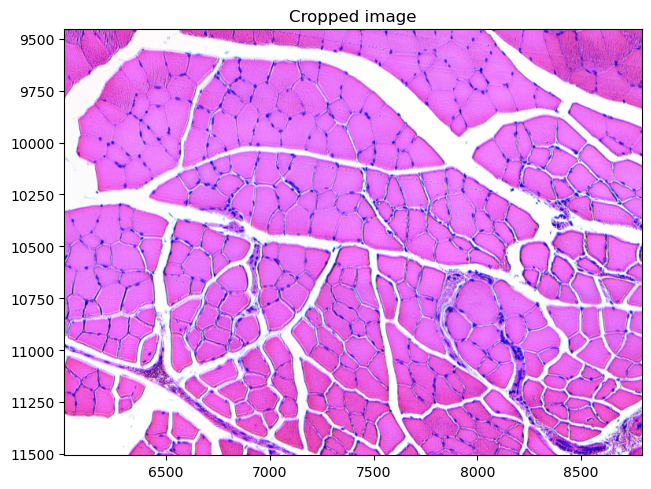

In [67]:
#show the cropped data
sdata_cropped.pl.render_images("blocco1_hires_image").pl.show(coordinate_systems = "blocco1", title="Cropped image")

# Data Normalization and Dimensionality Reduction
Normalize data in order to prevent tecnical errror (low capture efficency of a bin, different sequencing depth).
In this analysis, we set the target_sum to None, so that after normalization, each cell segmentation bin has a total UMI count equal to the median of the total UMI count for all cell segmentation bins before normalization. 

In [68]:
import scanpy as sc

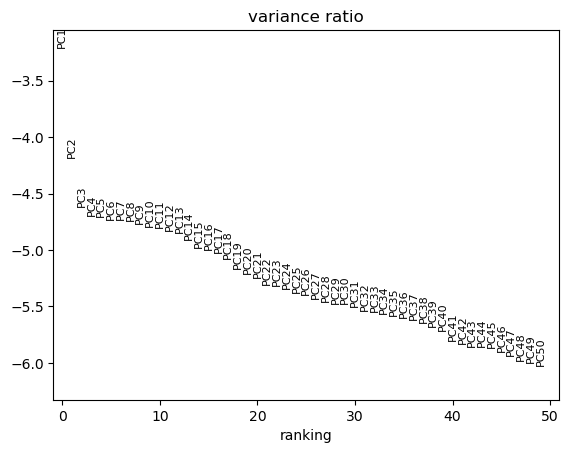

In [69]:
adata = sdata_cropped["square_008um"] 
sc.pp.normalize_total(adata, target_sum=None)
sc.pp.log1p(adata)
sc.tl.pca(adata)

#elbow plt
sc.pl.pca_variance_ratio(adata, log=True, n_pcs = 50)

In [21]:
adata.obsm["X_pca"][:, :2]

array([[-0.02783512, -0.02478447],
       [-0.20795088,  1.0690781 ],
       [ 0.5332627 ,  0.0932821 ],
       ...,
       [ 0.27236697,  1.3202883 ],
       [ 0.77969575,  0.26232907],
       [-0.70875746,  0.7308066 ]], shape=(546, 2), dtype=float32)

# Clustering and UMAP visualization

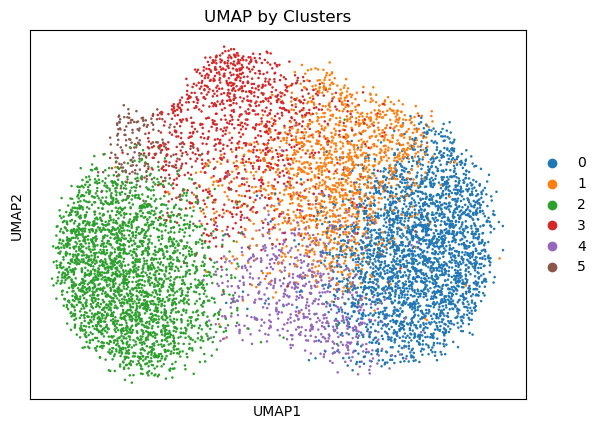

CPU times: user 30.5 s, sys: 701 ms, total: 31.2 s
Wall time: 30.5 s


In [70]:
%%time

# neighborhood and clustering resolution
RES = 0.8 # clustering resolution
NEIGHBORS = 10  # number of neighbors

MIN_DIST=0.5 #default 0.5
SPREAD=2 #default 1

sc.pp.neighbors(adata, n_neighbors=NEIGHBORS, use_rep="X_pca",metric="correlation")
sc.tl.leiden(adata, flavor="igraph", key_added="clusters", resolution=RES,random_state=0)
sc.tl.umap(adata)  

#plot UMAP
sc.pl.umap(adata, color=["clusters"], title="UMAP by Clusters")




# Marker Gene identification and Cluster Annotation

In [19]:
adata.var_names[:10]

Index(['Xkr4', 'Gm1992', 'Gm19938', 'Gm37381', 'Rp1', 'Sox17', 'Gm37587',
       'Gm37323', 'Mrpl15', 'Lypla1'],
      dtype='str')

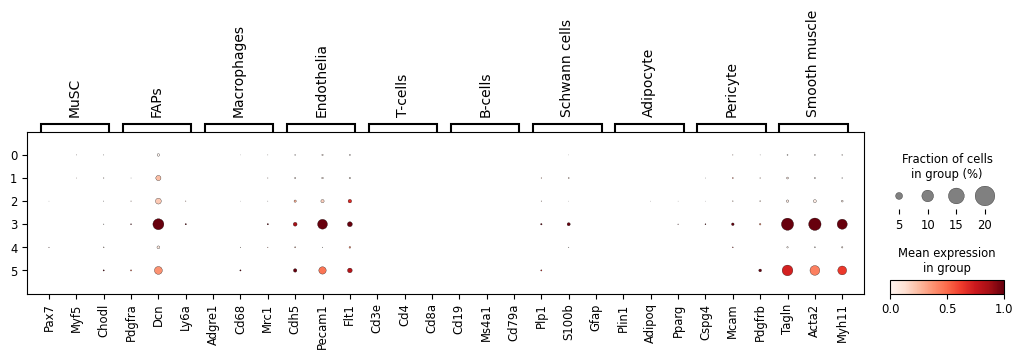

In [71]:
marker_genes_muscle = {
    "MuSC": ["Pax7", "Myf5", "Chodl"],
    "FAPs": ["Pdgfra", "Dcn", "Ly6a"],
    "Macrophages": ["Adgre1", "Cd68", "Mrc1"],
    "Endothelia": ["Cdh5", "Pecam1", "Flt1"],
    "T-cells": ["Cd3e", "Cd4", "Cd8a"],
    "B-cells": ["Cd19", "Ms4a1", "Cd79a"],
    "Schwann cells": ["Plp1", "S100b", "Gfap"],
    "Adipocyte": ["Plin1", "Adipoq", "Pparg"],
    "Pericyte": ["Cspg4", "Mcam", "Pdgfrb"],
    "Smooth muscle": ["Tagln", "Acta2", "Myh11"] # Myh11 è molto specifico
}

sc.pl.dotplot(adata, var_names = marker_genes_muscle, groupby="clusters", standard_scale="var")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.032520324..1.004065].


INFO     Successfully extracted 7 colors from 'clusters_colors' in table 'square_008um'.                           


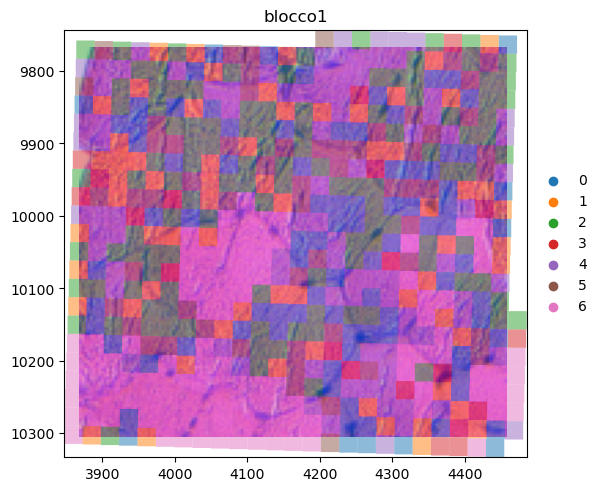

In [26]:
sdata_cropped.pl.render_images("blocco1_hires_image") \
    .pl.render_shapes(
        "intissue_008um", 
        color = 'clusters', 
        fill_alpha=0.5,   # Prova un valore molto basso come 0.2 o 0.3
        outline=True,     # Togliamo il bordo per ora, così non "sporca" l'immagine
    ).pl.show(coordinate_systems="blocco1")

In [27]:


# 1. Calcoliamo i geni marker per ogni cluster
sc.tl.rank_genes_groups(adata, groupby='clusters', method='wilcoxon')

# 2. Vediamo i top 5 geni per ogni cluster in una tabella
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
import pandas as pd
markers_df = pd.DataFrame(
    {group: result['names'][group][:5] for group in groups}
)
print(markers_df)

        0       1      2     3        4      5       6
0  Atp2a1  mt-Co3  Actn3  Tpm2    Aldoa   Myl1    Myh1
1   Pvalb  Atp2a1  Tnnc2  Myh4    Casq1  Tnni2      Mb
2   Mylpf    Myh4    Ckm   Ttn  Tmem38a    Ckm    Tpm2
3    Myh4   Acta1   Myh4   Neb     Pygm  Pvalb  mt-Co2
4    Ryr1   Tnnt3   Tpm1   Ckm     Pfkm   Tpm1    Car3


# marker quantification
Since in cluster 3 i see the presence of genes associated to FAPs try to visualize where (spatially) theese genes are expressed

In [83]:

FAPs= ["Pdgfra", "Dcn", "Ly6a"]
MuSC = ["Pax7", "Myf5", "Chodl"]

In [73]:
adata[: ,"Myh4"].X.sum(axis=0)

matrix([[8327.144]], dtype=float32)

In [75]:
adata = sdata_cropped["square_008um"]

In [76]:
adata

AnnData object with n_obs × n_vars = 9076 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region', 'clusters'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs', 'log1p', 'pca', 'neighbors', 'clusters', 'umap', 'clusters_colors'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [ ]:
marker_quantification = {}
for marker in FAPs:
    if marker in adata.var_names:
        marker_quantification[marker] = adata[:, marker].X.sum(axis=0) # sum by column

marker_quantification

{'Pdgfra': matrix([[4.6189713]], dtype=float32),
 'Dcn': matrix([[180.3171]], dtype=float32),
 'Ly6a': matrix([[2.8567772]], dtype=float32)}

In [ ]:
#add a column representing a type of nucleo, for each row sum all the column correponding to the given marker
adata.obs["FAPs"]= adata[:, FAPs].X.sum(axis=1)
adata.obs["Musc"] = adata[:, MuSC].X.sum(axis=1)

SyntaxError: invalid syntax (640584286.py, line 2)

In [48]:
adata

AnnData object with n_obs × n_vars = 546 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'location_id', 'region', 'clusters', 'Faps'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs', 'log1p', 'pca', 'neighbors', 'clusters', 'umap', 'clusters_colors', 'rank_genes_groups'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

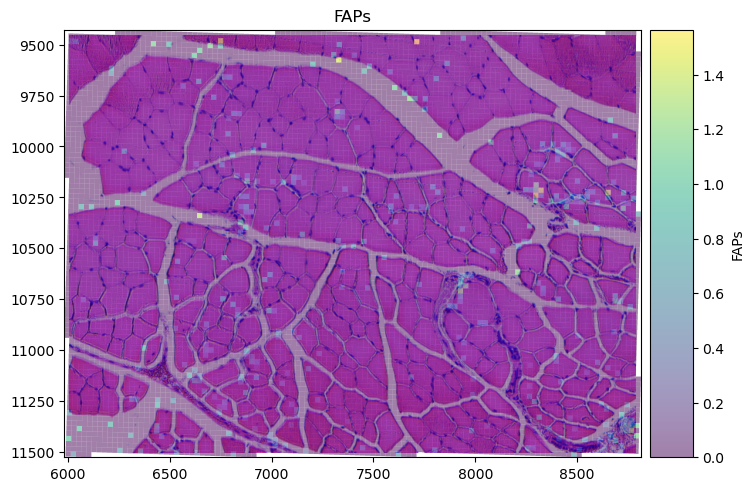

In [ ]:
#colored bins cover all the image, so i try to use transparent bins
sdata_cropped.pl.render_images("blocco1_hires_image") \
    .pl.render_shapes(
        "intissue_008um", 
        "FAPs", 
        fill_alpha=0.5,  
        outline=True,     # Togliamo il bordo per ora, così non "sporca" l'immagine
    ).pl.show(coordinate_systems="blocco1", title = "FAPs")